In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

plt.style.use("seaborn-v0_8")

df = pd.read_csv('modelling_dataset_top5.csv', parse_dates=["date"])

<font size="5">Business Demand Analysis</font>

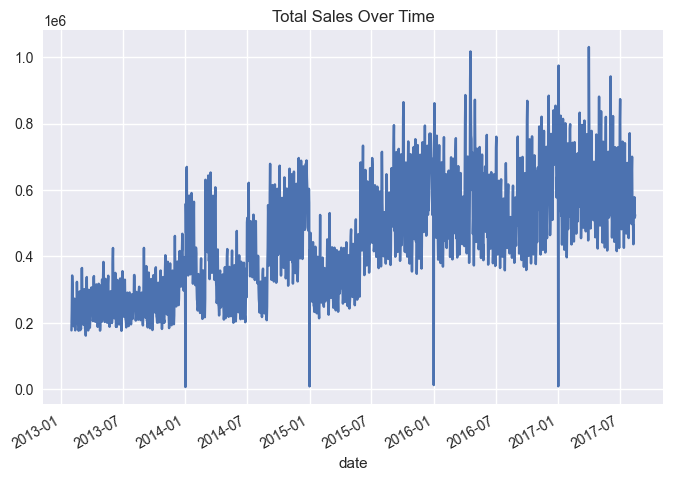

In [2]:
#Trend
daily_total = df.groupby("date")["sales"].sum()

plt.Figure(figsize=(12,5))
daily_total.plot()
plt.title("Total Sales Over Time")
plt.show()

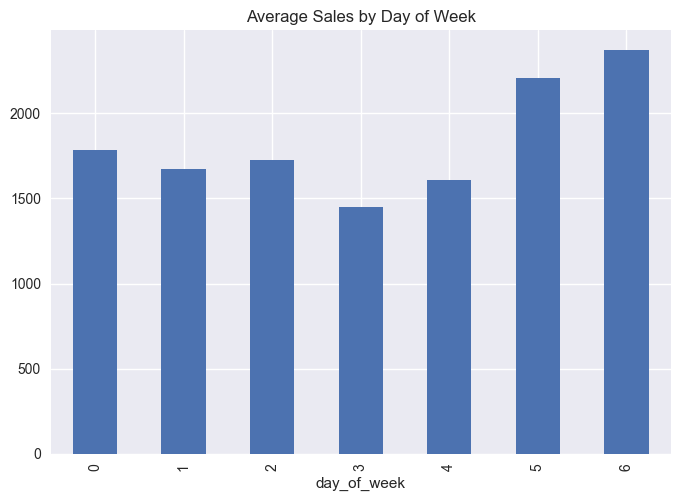

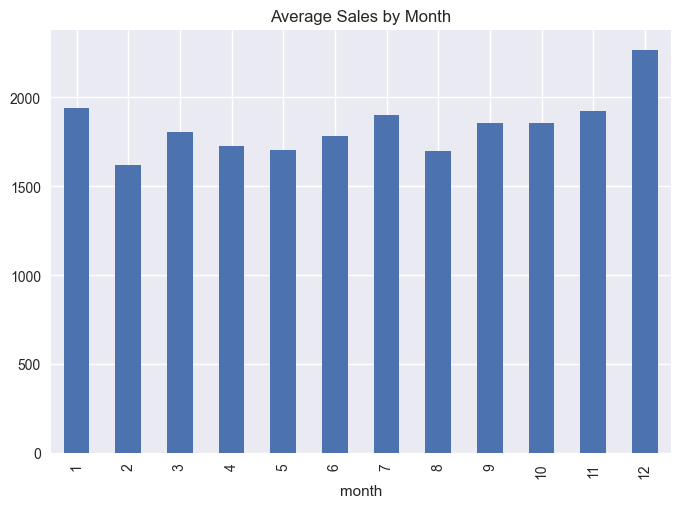

In [3]:
#Seasonality By Day of Week
dow = df.groupby("day_of_week")["sales"].mean()

plt.Figure(figsize=(8,4))
dow.plot(kind="bar")
plt.title("Average Sales by Day of Week")
plt.show()

#Seasonality By Month
month = df.groupby("month")["sales"].mean()

plt.Figure(figsize=(8,4))
month.plot(kind="bar")
plt.title("Average Sales by Month")
plt.show()

In [4]:
#Intermittent Demand Analysis
intermittent = (
    df.groupby(['store_nbr','family'])['sales']
    .apply(lambda x: (x == 0).mean())
    .reset_index(name='zero_ratio')
)

intermittent['demand_type'] = np.where(
    intermittent['zero_ratio'] > 0.4,
    'Intermittent',
    'Regular'
)

intermittent['demand_type'].value_counts()

demand_type
Regular         212
Intermittent     26
Name: count, dtype: int64

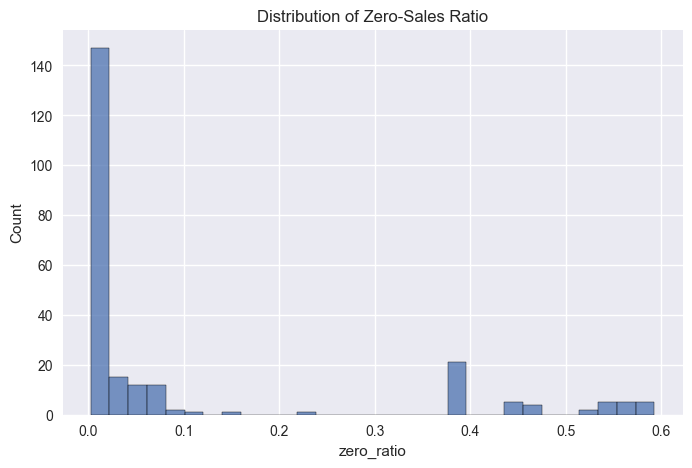

In [5]:
#Intermittent Demand Analysis Graph
plt.figure(figsize=(8,5))
sns.histplot(intermittent['zero_ratio'], bins=30)
plt.title("Distribution of Zero-Sales Ratio")
plt.show()

In [6]:
#Demand Variability Analysis
variability = (
    df.groupby(['store_nbr','family'])['sales']
    .agg(['mean','std'])
    .reset_index()
)
variability['cv'] = variability['std'] / variability['mean']

def classify_xyz(cv):
    if cv < 0.5:
        return "X"
    elif cv < 1:
        return "Y"
    else:
        return "Z"
    
variability['variability_class'] = variability['cv'].apply(classify_xyz)
variability['variability_class'].value_counts()

variability_class
X    130
Y     81
Z     27
Name: count, dtype: int64

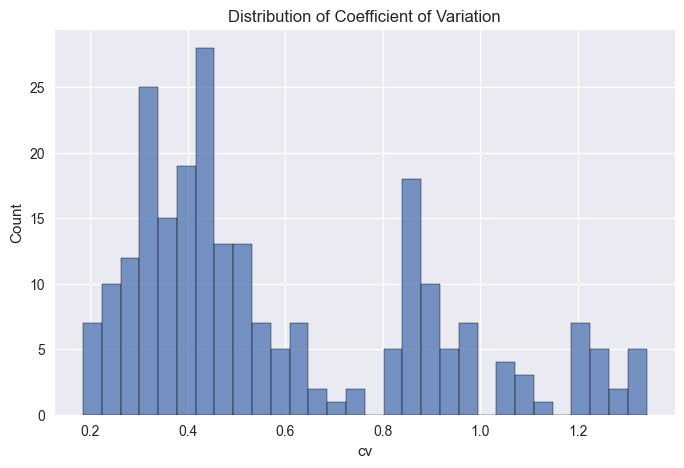

In [7]:
#Demand Variability Analysis Graph
plt.figure(figsize=(8,5))
sns.histplot(variability['cv'], bins=30)
plt.title("Distribution of Coefficient of Variation")
plt.show()

<font size="5">Product Segmentation</font>

In [8]:
#ABC Analysis
abc = (
    df.groupby(["store_nbr","family"])["sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

abc["cum_revenue"] = abc["sales"].cumsum()
abc["cum_pct"] = abc["cum_revenue"] / abc["sales"].sum()
#Classification
def abc_class(p):
    if p <= 0.7:
        return "A"
    elif p <= 0.9:
        return "B"
    else:
        return "C"
    
abc["ABC_class"] = abc["cum_pct"].apply(abc_class)
#Check Distribution
abc["ABC_class"].value_counts()

ABC_class
C    86
A    83
B    69
Name: count, dtype: int64

In [9]:
#XYZ Analysis
xyz = (
    df.groupby(["store_nbr","family"])["sales"]
    .agg(["mean","std"])
    .reset_index()
)

xyz["cv"] = xyz["std"] / xyz["mean"]
#Classification
def xyz_class(cv):
    if cv < 0.5:
        return "X"
    elif cv < 1:
        return "Y"
    else:
        return "Z"
    
xyz["XYZ_class"] = xyz["cv"].apply(xyz_class)
#Check Distribution
xyz["XYZ_class"].value_counts()

XYZ_class
X    130
Y     81
Z     27
Name: count, dtype: int64

In [10]:
#Merge ABC+XYZ
segmentation = abc.merge(
    xyz[["store_nbr","family","XYZ_class"]],
    on=["store_nbr","family"],
    how="left"
)
segmentation["Segment"] = segmentation["ABC_class"] + segmentation["XYZ_class"]
#Check
segmentation["Segment"].value_counts()

Segment
AX    58
CX    38
BX    34
CY    32
BY    27
AY    22
CZ    16
BZ     8
AZ     3
Name: count, dtype: int64

<font size="5">Forecasting Diagnostics</font>

In [11]:
#Autocorrelation Strength
corr_matrix = df[['sales','lag_1','lag_7','lag_14','rolling_mean_7']].corr()
corr_matrix


,sales,lag_1,lag_7,lag_14,rolling_mean_7
sales,1.000000,0.877330,0.902263,0.891493,0.905540
lag_1,0.877330,1.000000,0.851160,0.836571,0.920649
lag_7,0.902263,0.851160,1.000000,0.902247,0.920571
lag_14,0.891493,0.836571,0.902247,1.000000,0.884720
rolling_mean_7,0.905540,0.920649,0.920571,0.884720,1.000000


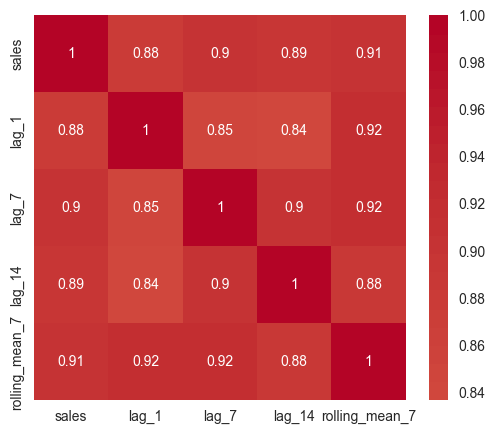

In [12]:
#Autocorrelation Strength Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.show()

In [13]:
#Promotion Impact
promo_effect = df.groupby("promo_flag")["sales"].mean()
promo_effect

promo_flag
0    1134.805381
1    2449.254935
Name: sales, dtype: float64

In [14]:
#Promotion uplift ratio:
promo_uplift = (
    promo_effect[1] / promo_effect[0]
)

print("Promotion uplift ratio:", promo_uplift)

Promotion uplift ratio: 2.1583039496323315


In [15]:
print(df['is_holiday'].value_counts(dropna=False))
holiday_effect = df.groupby("is_holiday")["sales"].mean()
print(holiday_effect)
print("Index values:", holiday_effect.index.tolist())

is_holiday
0    334448
1     58690
Name: count, dtype: int64
is_holiday
0    1805.077787
1    1982.695145
Name: sales, dtype: float64
Index values: [0, 1]


In [16]:
#Holiday Impact
df['is_holiday'] = df['is_holiday'].astype(int)
holiday_effect = df.groupby("is_holiday")["sales"].mean()
holiday_effect

is_holiday
0    1805.077787
1    1982.695145
Name: sales, dtype: float64

In [17]:
holiday_uplift = holiday_effect.loc[1] / holiday_effect.loc[0]
print("Holiday uplift ratio:", holiday_uplift)

Holiday uplift ratio: 1.0983987277474205


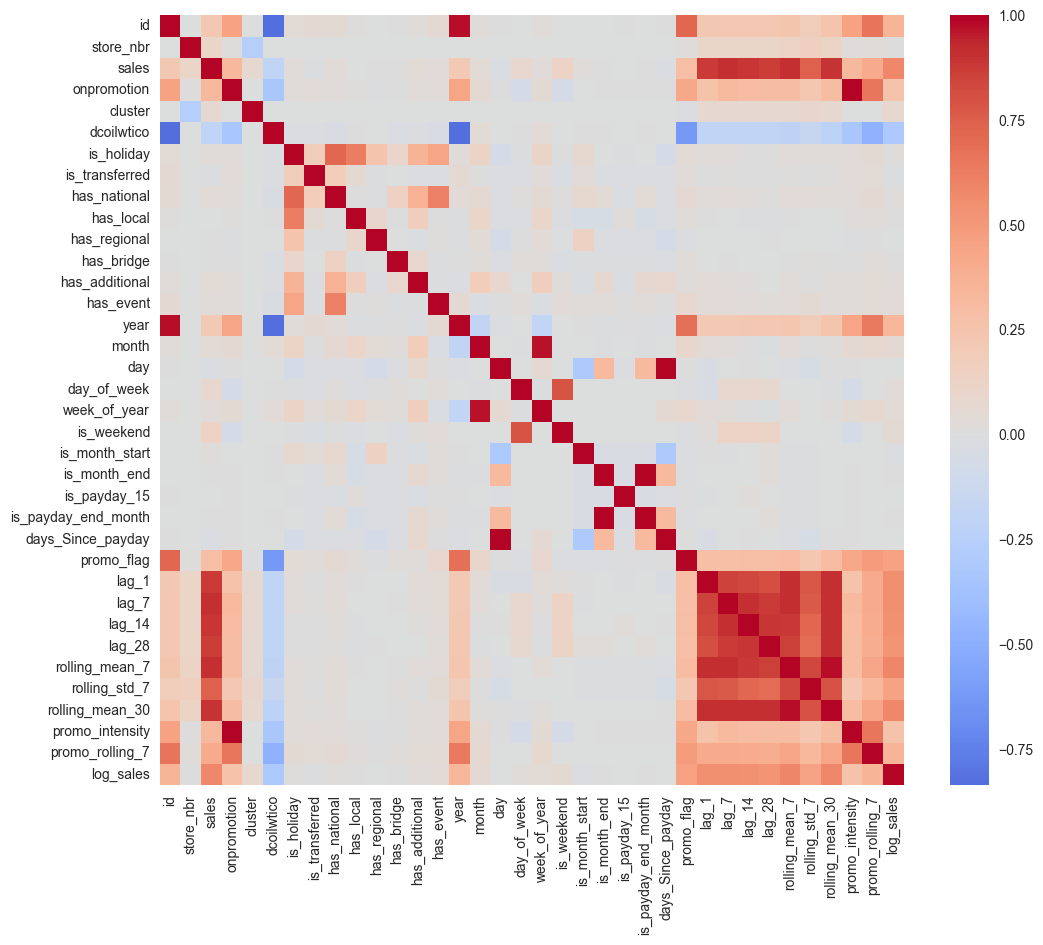

In [18]:
#Feature Correlation
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.show()

In [19]:
segmentation.to_csv("segmentation.csv", index=False)